# Proyek Klasifikasi Gambar: garbage-classification
- **Nama:** Aidil Baihaqi
- **Email:** cacc252d6y2591@student.devacademy.id
- **ID Dicoding:** cacc252d6y1914

## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install tensorflowjs split-folders

import os
import shutil
import zipfile
import splitfolders
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau

os.environ["KAGGLE_USERNAME"] = "aidilbaihaqi"
os.environ["KAGGLE_KEY"] = "ddfa0f57693d6afcfd42e5445aae3984"

print("✅ Semua Library berhasil di-import dan akses Kaggle siap!")

✅ Semua Library berhasil di-import dan akses Kaggle siap!


## Data Preparation

### Data Loading

In [26]:
!kaggle datasets download -d mostafaabla/garbage-classification

print("\nSedang mengekstrak dataset utama...")
local_zip = '/content/garbage-classification.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/dataset_asli')
zip_ref.close()

base_dir_asli = '/content/dataset_asli/garbage_classification'
print(f"✅ Data Loading Selesai! Total kelas ditemukan: {len(os.listdir(base_dir_asli))}")

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)

Sedang mengekstrak dataset utama...
✅ Data Loading Selesai! Total kelas ditemukan: 12


### Data Preprocessing

#### Split Dataset

In [27]:
print("Memproses pembagian dataset (Split Folders)...")
splitfolders.ratio(base_dir_asli, output="/content/dataset_split", seed=42, ratio=(.8, .1, .1))

train_dir = '/content/dataset_split/train'
val_dir = '/content/dataset_split/val'
test_dir = '/content/dataset_split/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\nMempersiapkan Data Training:")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=64, class_mode='categorical'
)

print("\nMempersiapkan Data Validation:")
validation_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=64, class_mode='categorical'
)

print("\nMempersiapkan Data Testing:")
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=64, class_mode='categorical', shuffle=False
)

Memproses pembagian dataset (Split Folders)...


Copying files: 15515 files [00:07, 2106.51 files/s]



Mempersiapkan Data Training:
Found 12409 images belonging to 12 classes.

Mempersiapkan Data Validation:
Found 1545 images belonging to 12 classes.

Mempersiapkan Data Testing:
Found 1561 images belonging to 12 classes.


## Modelling

In [28]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])

class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.95 and logs.get('val_accuracy') >= 0.95):
            print("\n✅ Target Akurasi 95% Tembus! Training dihentikan.")
            self.model.stop_training = True

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

print("\n Memulai proses training...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[TargetCallback(), reduce_lr]
)

/tmp/ipykernel_2645/3300312766.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))



 Memulai proses training...
Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 121s 557ms/step - accuracy: 0.7237 - loss: 0.8753 - val_accuracy: 0.8531 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 78s 400ms/step - accuracy: 0.8622 - loss: 0.4605 - val_accuracy: 0.8861 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 78s 400ms/step - accuracy: 0.8897 - loss: 0.3592 - val_accuracy: 0.9146 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 77s 395ms/step - accuracy: 0.9055 - loss: 0.3117 - val_accuracy: 0.9068 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 77s 395ms/step - accuracy: 0.9146 - loss: 0.2699 - val_accuracy: 0.8997 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9272 - loss: 0.2381
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
194/194 ━━━━━━━━━━━━━━━━━━━━ 7

## Evaluasi dan Visualisasi


--- Evaluasi Model pada Data Testing ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 558ms/step - accuracy: 0.9193 - loss: 0.3152
✅ Akurasi Test Set: 91.93%



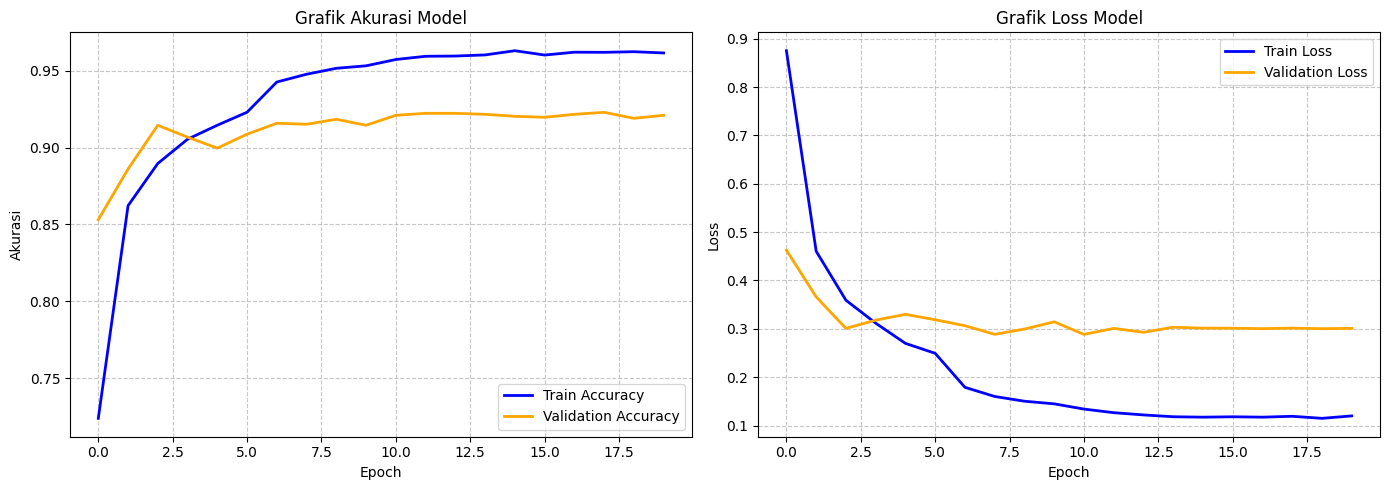

In [29]:
print("\n--- Evaluasi Model pada Data Testing ---")
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Akurasi Test Set: {test_acc * 100:.2f}%\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Konversi Model

In [33]:
import tensorflow as tf

export_dir = 'saved_model_dir'
model.export(export_dir)
print("✅ SavedModel siap.")

converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ TF-Lite siap (Terkompresi).")

print("Mengonversi ke TFJS...")
!tensorflowjs_converter --input_format=tf_saved_model saved_model_dir tfjs_model
print("✅ TFJS siap.")

Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_362')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  139580103146576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139580103146192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139580119547728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139580119544656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139580103147152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139580119546192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576122737104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576122737296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576122736720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576122738448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1395761227

## Inference (Optional)

Silakan upload gambar sampah untuk diuji prediksi:


Saving image_2026-04-29_155743050.png to image_2026-04-29_155743050.png


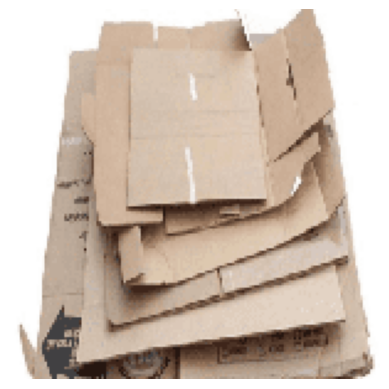

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step

--- HASIL PREDIKSI ---
File Output : image_2026-04-29_155743050.png
Klasifikasi : CARDBOARD
Kepercayaan : 100.00%


In [35]:
class_labels = list(train_generator.class_indices.keys())

print("Silakan upload gambar sampah untuk diuji prediksi:")
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    classes = model.predict(x)
    predicted_class_index = np.argmax(classes[0])
    predicted_label = class_labels[predicted_class_index]
    confidence_score = classes[0][predicted_class_index] * 100

    print(f"\n--- HASIL PREDIKSI ---")
    print(f"File Output : {fn}")
    print(f"Klasifikasi : {predicted_label.upper()}")
    print(f"Kepercayaan : {confidence_score:.2f}%")